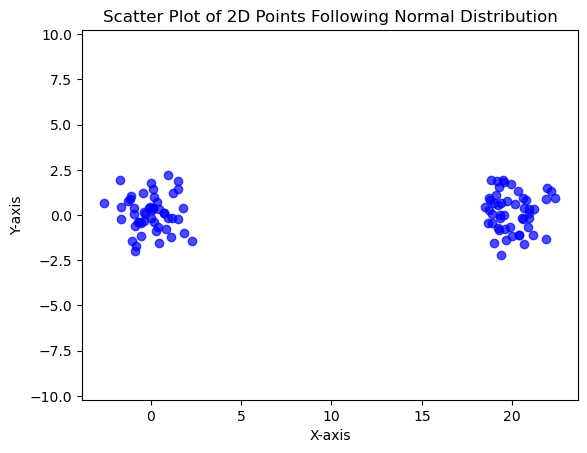

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)  # Seed for reproducibility
# Parameters
mean = [0, 0]  # Mean for x and y
std_dev = [1, 1]  # Standard deviation for x and y
num_points_per_cluster = 50  # Number of points to generate

# Generate points
points1 = np.random.normal(loc=[0,0], scale=std_dev, size=(num_points_per_cluster, 2))
points3 = np.random.normal(loc=[20, 0], scale=std_dev, size=(num_points_per_cluster, 2))
D1 = np.vstack([points1, points3])
# Scatter plot
# plt.figure(figsize=(8, 6))
plt.scatter(D1[:, 0], D1[:, 1], alpha=0.7, color='blue')
plt.title('Scatter Plot of 2D Points Following Normal Distribution')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
# plt.grid()
plt.axis('equal')  # Ensure equal scaling
plt.show()

In [2]:
from graph_mph import compute_absolute_MPH0_multi_critical_filtration, compute_grid_H0
from scipy.spatial import distance
# compute the absolute MPH0 with multiple critical values
n = D1.shape[0]
pd_mat = distance.squareform(distance.pdist(D1)) 
betti0s, betti1s, betti2s = compute_absolute_MPH0_multi_critical_filtration(pd_mat)
H0_grid = compute_grid_H0(50, [0, np.max(pd_mat)], [-n, 0], betti0s, betti1s, betti2s)

In [3]:
unique, counts = np.unique(H0_grid, return_counts=True)
print("Frequency of each value in H_0 values:")
for u, c in zip(unique, counts):
    print(f"{u} : {c} times")

Frequency of each value in H_0 values:
0 : 973 times
1 : 778 times
2 : 744 times
3 : 2 times
5 : 1 times
24 : 1 times
100 : 1 times


In [8]:
import matplotlib.colors as mcolors

def draw_discrete_matrix(mat, x_range = None, y_range = None, discrete_colorbar=True):
    # Define the boundaries for the discrete color bar
    boundaries = np.arange(np.min(mat), np.max(mat) + 2) - 0.5
    norm = mcolors.BoundaryNorm(boundaries, plt.cm.viridis.N)

    # Plot the H_0 values with discrete color bar
    if x_range is None or y_range is None: # if no range is provided, use the default range
        plt.imshow(mat, origin='lower', aspect='auto', norm=norm, cmap='viridis')
    else: # if range is provided, use the provided range
        plt.imshow(mat, extent=(*x_range, *y_range), origin='lower', aspect='auto', norm=norm, cmap='viridis')

    if discrete_colorbar:
        cbar = plt.colorbar(ticks=np.arange(np.min(mat), np.max(mat) + 1))
    else:
        cbar = plt.colorbar()
    cbar.set_label('$H_0$ values')
    plt.title('$H_0$ values')
    plt.xlabel('Radius')
    plt.ylabel('Degree')
    plt.show()

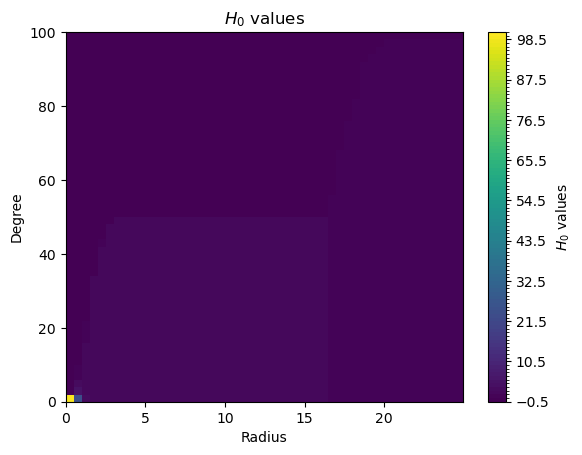

In [10]:
H0_grid_flipped = np.flip(H0_grid, axis=0)
draw_discrete_matrix(H0_grid_flipped, [0, np.max(pd_mat)], [0, n], discrete_colorbar=False)

# draw_discrete_matrix(H0_grid, [0, np.max(pd_mat)], [-n, 0], 
#                      discrete_colorbar=False)

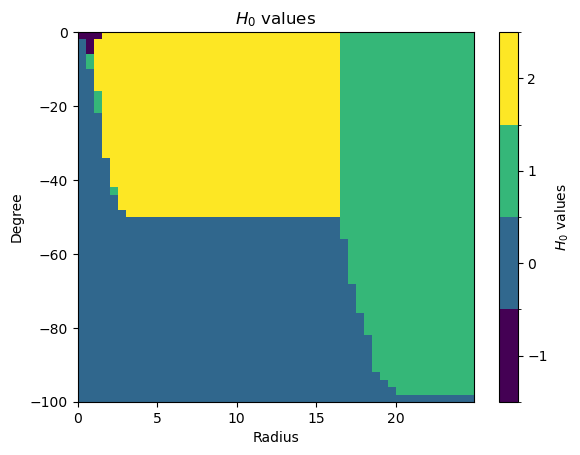

In [6]:
# mask the H0_values with the value >= 3 as -1
H0_grid_masked = np.where(H0_grid >= 3, -1, H0_grid)
draw_discrete_matrix(H0_grid_masked, [0, np.max(pd_mat)], [-n, 0] )

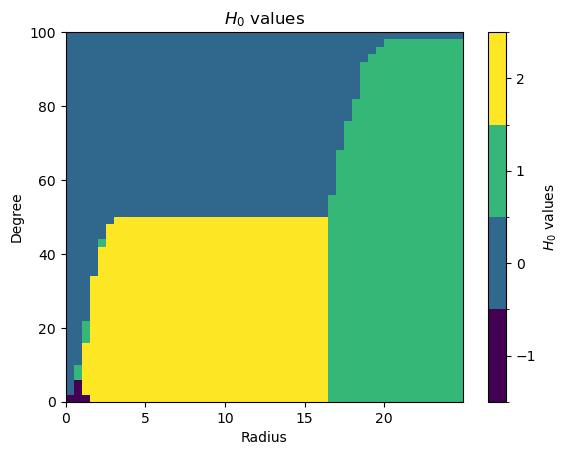

In [ ]:
# reverse the matrix along the degree axis
H0_grid_masked_flipped = np.flip(H0_grid_masked, axis=0)
draw_discrete_matrix(H0_grid_masked_flipped, [0, np.max(pd_mat)], [0, n])

## Smaller Two clusters

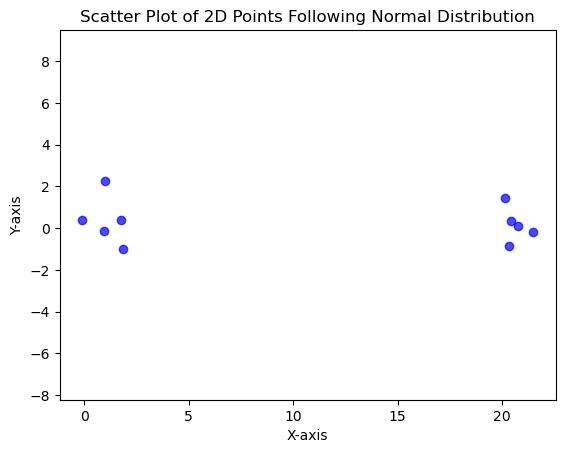

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)  # Seed for reproducibility
# Parameters
mean = [0, 0]  # Mean for x and y
std_dev = [1, 1]  # Standard deviation for x and y
num_points_per_cluster = 5  # Number of points to generate

# Generate points
points1 = np.random.normal(loc=[0,0], scale=std_dev, size=(num_points_per_cluster, 2))
points3 = np.random.normal(loc=[20, 0], scale=std_dev, size=(num_points_per_cluster, 2))
D1 = np.vstack([points1, points3])
# Scatter plot
# plt.figure(figsize=(8, 6))
plt.scatter(D1[:, 0], D1[:, 1], alpha=0.7, color='blue')
plt.title('Scatter Plot of 2D Points Following Normal Distribution')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
# plt.grid()
plt.axis('equal')  # Ensure equal scaling
plt.show()

In [2]:
from graph_mph import compute_absolute_MPH0_multi_critical_filtration, compute_grid_H0
from scipy.spatial import distance
# compute the absolute MPH0 with multiple critical values
n = D1.shape[0]
pd_mat = distance.squareform(distance.pdist(D1)) 
betti0s, betti1s, betti2s = compute_absolute_MPH0_multi_critical_filtration(pd_mat)
H0_grid = compute_grid_H0(50, [0, np.max(pd_mat)], [-n, 0], betti0s, betti1s, betti2s)

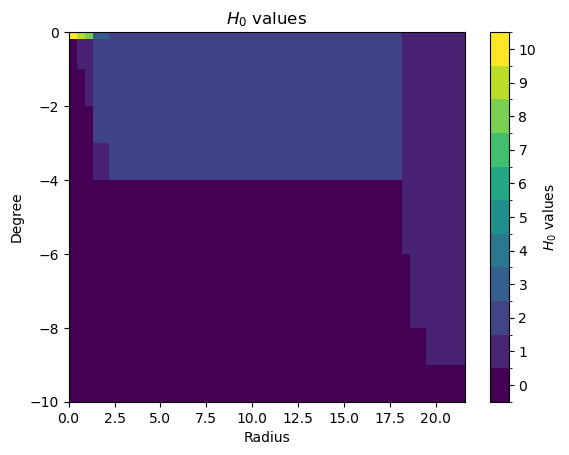

In [10]:
draw_discrete_matrix(H0_grid, [0, np.max(pd_mat)], [-n, 0])

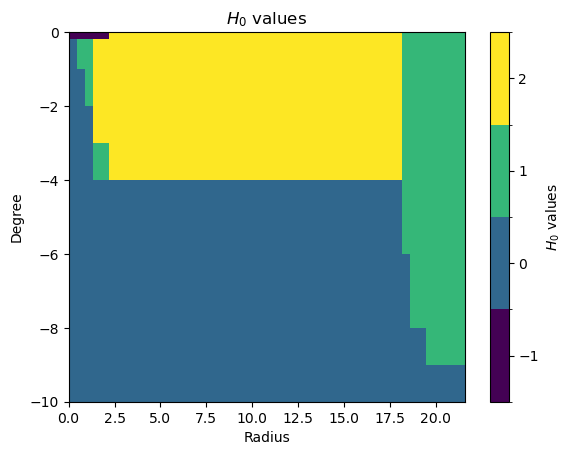

In [11]:
# mask the H0_values with the value >= 3 as -1
H0_grid_masked = np.where(H0_grid >= 3, -1, H0_grid)
draw_discrete_matrix(H0_grid_masked, [0, np.max(pd_mat)], [-n, 0])

## Two clusters with noise

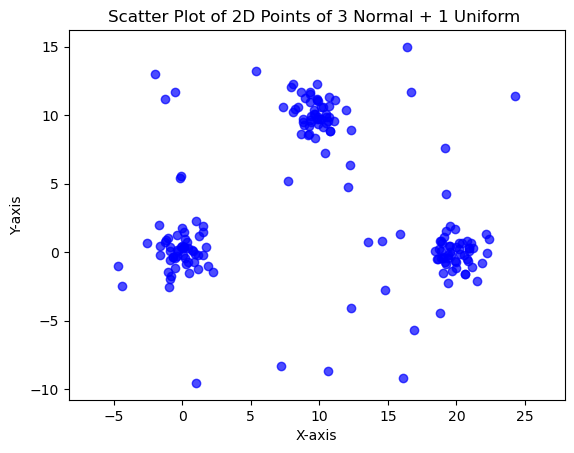

In [19]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)  # Seed for reproducibility
# Parameters
mean = [0, 0]  # Mean for x and y
std_dev = [1, 1]  # Standard deviation for x and y
num_points_per_cluster = 50  # Number of points to generate

# Generate points
points1 = np.random.normal(loc=[0, 0], scale=std_dev, size=(num_points_per_cluster, 2))
points2 = np.random.uniform(low=[-5, -10], high=[25, 15], size=(30, 2))
points3 = np.random.normal(loc=[20, 0], scale=std_dev, size=(num_points_per_cluster, 2))
points4 = np.random.normal(loc=[10, 10], scale=std_dev, size=(num_points_per_cluster, 2))
D1 = np.vstack([points1, points2, points3, points4])
# Scatter plot
# plt.figure(figsize=(8, 6))
plt.scatter(D1[:, 0], D1[:, 1], alpha=0.7, color='blue')
plt.title('Scatter Plot of 2D Points of 3 Normal + 1 Uniform ')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
# plt.grid()
plt.axis('equal')  # Ensure equal scaling
plt.show()

In [16]:
from graph_mph import compute_absolute_MPH0_multi_critical_filtration, compute_grid_H0
from scipy.spatial import distance
n = D1.shape[0]
pd_mat = distance.squareform(distance.pdist(D1))
betti0s, betti1s, betti2s = compute_absolute_MPH0_multi_critical_filtration(pd_mat)

Frequency of each value in H_0 values:
0 : 686 times
1 : 1689 times
2 : 27 times
3 : 87 times
4 : 2 times
5 : 1 times
7 : 1 times
8 : 1 times
15 : 1 times
19 : 1 times
23 : 1 times
29 : 1 times
51 : 1 times
180 : 1 times


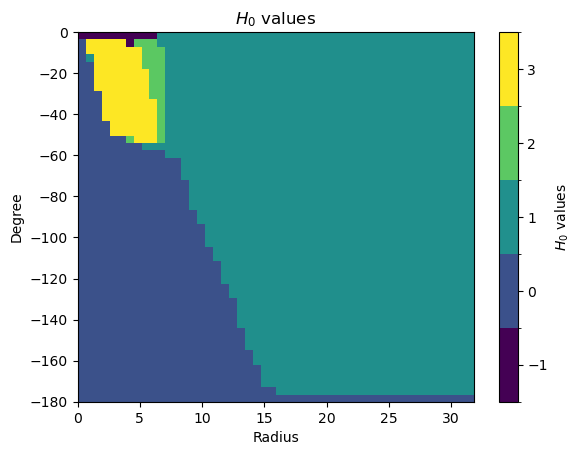

In [17]:
H0_grid = compute_grid_H0(50, [0, np.max(pd_mat)], [-n, 0], betti0s, betti1s, betti2s)
mesh_size = H0_grid.size
unique, counts = np.unique(H0_grid, return_counts=True)
print("Frequency of each value in H_0 values:")
noise_values = [] # low frequency values
for u, c in zip(unique, counts):
    print(f"{u} : {c} times")
    if c <= 0.01 * mesh_size:
        noise_values.append(u)

# mask the entries in H0_values of its frequency <= 10 as -1
H0_grid_masked = np.where(H0_grid >= min(noise_values), -1, H0_grid)
draw_discrete_matrix(H0_grid_masked, [0, np.max(pd_mat)], [-n, 0])

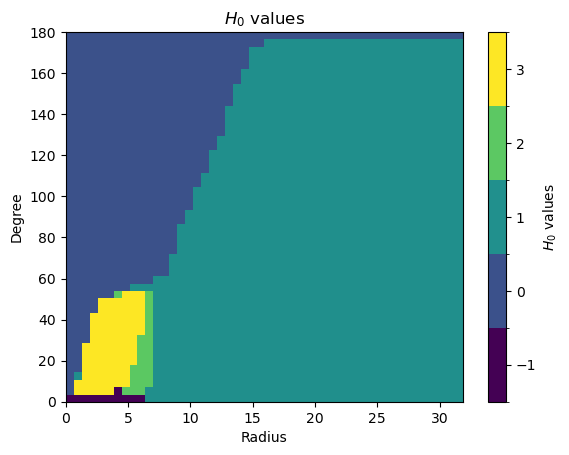

In [18]:
# reverse the matrix along the degree axis
H0_grid_masked_flipped = np.flip(H0_grid_masked, axis=0)
draw_discrete_matrix(H0_grid_masked_flipped, [0, np.max(pd_mat)], [0, n])

### Question: Persistence Image not good?

In [11]:
# persistence images
import numpy as np

def gaussian_2d(x, y, x0, y0, sigma):
    """
    Calculate the value of a 2D Gaussian at point (x, y) centered at (x0, y0) with standard deviation sigma.
    x, y: can be scalars or numpy arrays
    x0, y0, sigma: scalars
    """
    return np.exp(-((x - x0) ** 2 + (y - y0) ** 2) / (2 * sigma ** 2))

def sum_gaussians(centers, x_range, y_range,  sigma, m):
    """Sum over Gaussians centered at given points and discretize into an m x m matrix."""
    # Create a grid of points within the specified range
    x = np.linspace(x_range[0], x_range[1], m)
    y = np.linspace(y_range[0], y_range[1], m)
    X, Y = np.meshgrid(x, y)
    
    # Initialize the matrix to store the sum of Gaussians
    Z = np.zeros((m, m))
    
    # # Sum over each Gaussian centered at the given points
    for (x0, y0) in centers:
        Z += gaussian_2d(X, Y, x0, y0, sigma)
    return Z

In [16]:
# get rid of betti0s, bett1s, bett2s with y-coordinate <= -2
betti0s_filtered = [betti0 for betti0 in betti0s if betti0[1] < -5]
betti1s_filtered = [betti1 for betti1 in betti1s if betti1[1] < -5]
betti2s_filtered = [betti2 for betti2 in betti2s if betti2[1] < -5]

In [26]:
def compute_H0_persistence_image(betti0s, betti1s, betti2s,
                            x_range, y_range, m = 100, sigma = 0.2):
    # compute PIs
    # Spread of the Gaussian
    # Size of the matrix
    centers0 = betti0s
    centers1 = betti1s
    centers2 = betti2s
    # Compute the sum of Gaussians with automatic grid range determination
    Z0 = sum_gaussians(centers0, x_range, y_range, sigma, m)
    Z1 = sum_gaussians(centers1, x_range, y_range, sigma, m)
    Z2 = sum_gaussians(centers2, x_range, y_range, sigma, m)
    return Z0 - Z1 + Z2

x_range, y_range = [0, np.max(pd_mat)], [-n, 0]

PI_mat = compute_H0_persistence_image(betti0s_filtered, betti1s_filtered, betti2s_filtered, x_range, y_range, m = 100, sigma=1.)

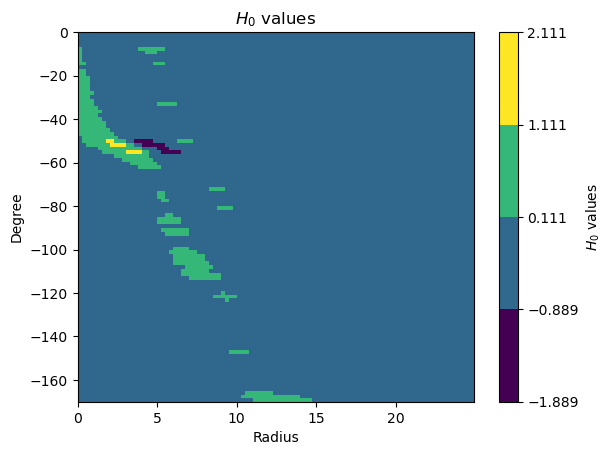

In [27]:
draw_discrete_matrix(PI_mat, x_range, y_range, discrete_colorbar=False)